In [62]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [63]:
def quat_to_rotmat(q):
    q = np.asarray(q, dtype=float)
    q = q / np.linalg.norm(q)   # normalize

    w, x, y, z = q

    R = np.array([
        [1 - 2*(y**2 + z**2),  2*(x*y - z*w),      2*(x*z + y*w)],
        [2*(x*y + z*w),        1 - 2*(x**2 + z**2), 2*(y*z - x*w)],
        [2*(x*z - y*w),        2*(y*z + x*w),      1 - 2*(x**2 + y**2)]
    ])

    return R

In [64]:
def T_translate(t):
    T = np.eye(4)
    T[:3, 3] = np.asarray(t).reshape(3,)
    return T

def T_rotate(R):
    T = np.eye(4)
    T[:3, :3] = R
    return T

In [65]:
Rz_cw_90 = np.array([[0.0,  1.0, 0.0],
                     [-1.0, 0.0, 0.0],
                     [0.0,  0.0, 1.0]])

In [66]:


csv_path = Path('/home/jestin/ThesisRepo/ML/TwoHand_L_Fist_R_Fist_filtered_butterworth_lp/glove_data_L_Fist_R_Fist_5s_3_2026-04-19_19-31-18_bw_lp_5.0hz.csv')
df = pd.read_csv(csv_path)
print(f'Loaded: {csv_path}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()


Loaded: /home/jestin/ThesisRepo/ML/TwoHand_L_Fist_R_Fist_filtered_butterworth_lp/glove_data_L_Fist_R_Fist_5s_3_2026-04-19_19-31-18_bw_lp_5.0hz.csv
Shape: 116 rows x 295 columns


,run_index,request_id,request_ts,left_recv_time_ms,left_glove_time_ms,left_time,right_recv_time_ms,right_glove_time_ms,right_time,left_hand,...,right_wrist_heading,right_wrist_pitch,right_wrist_roll,right_wrist_quat_w,right_wrist_quat_x,right_wrist_quat_y,right_wrist_quat_z,right_wrist_ax,right_wrist_ay,right_wrist_az
0,3,1,2026-04-19T19:31:21.157,1.776591e+12,133706.983435,-0.016427,1.776591e+12,130448.983854,-0.016422,LeftGlove,...,103.880128,-4.940062,-11.559076,0.612401,0.096395,-0.052594,-0.782803,-0.809958,1.449879,9.329719
1,3,2,2026-04-19T19:31:21.243,1.776591e+12,133756.929966,58.033478,1.776591e+12,130500.111011,59.043668,LeftGlove,...,103.906674,-5.220666,-11.827638,0.612064,0.099922,-0.052878,-0.782663,-0.888940,1.793150,9.754161
2,3,3,2026-04-19T19:31:21.249,1.776591e+12,133808.640375,114.352109,1.776591e+12,130550.948565,114.030589,LeftGlove,...,103.945571,-5.473902,-12.007133,0.611741,0.102605,-0.052667,-0.782629,-0.972920,1.967555,9.860021
3,3,4,2026-04-19T19:31:21.304,1.776591e+12,133861.896284,168.012142,1.776591e+12,130601.245156,164.723358,LeftGlove,...,103.973830,-5.603094,-12.082780,0.611598,0.103706,-0.052419,-0.782641,-1.011166,1.975733,9.716873
4,3,5,2026-04-19T19:31:21.311,1.776591e+12,133914.876446,219.248786,1.776591e+12,130651.135402,213.900276,LeftGlove,...,103.978620,-5.595585,-12.121187,0.611616,0.103671,-0.052716,-0.782616,-0.973106,1.973534,9.566257


In [67]:
ROW_SELECT = 0  # Change this to select different frames

LeftHand = {
    "Palm": np.array([df['left_palm_prox_quat_x'][ROW_SELECT], df['left_palm_prox_quat_y'][ROW_SELECT], df['left_palm_prox_quat_z'][ROW_SELECT], df['left_palm_prox_quat_w'][ROW_SELECT]]).T,
    "Thumb": {
        "Proximal": np.array([df['left_thumb_prox_quat_x'][ROW_SELECT], df['left_thumb_prox_quat_y'][ROW_SELECT], df['left_thumb_prox_quat_z'][ROW_SELECT], df['left_thumb_prox_quat_w'][ROW_SELECT]]).T,
        "Mid": np.array([df['left_thumb_mid_quat_x'][ROW_SELECT], df['left_thumb_mid_quat_y'][ROW_SELECT], df['left_thumb_mid_quat_z'][ROW_SELECT], df['left_thumb_mid_quat_w'][ROW_SELECT]]).T,
    },
    "Index": {
        "Proximal": np.array([df['left_index_prox_quat_x'][ROW_SELECT], df['left_index_prox_quat_y'][ROW_SELECT], df['left_index_prox_quat_z'][ROW_SELECT], df['left_index_prox_quat_w'][ROW_SELECT]]).T,
        "Mid": np.array([df['left_index_mid_quat_x'][ROW_SELECT], df['left_index_mid_quat_y'][ROW_SELECT], df['left_index_mid_quat_z'][ROW_SELECT], df['left_index_mid_quat_w'][ROW_SELECT]]).T
    },
    "Middle": {
        "Proximal": np.array([df['left_middle_prox_quat_x'][ROW_SELECT], df['left_middle_prox_quat_y'][ROW_SELECT], df['left_middle_prox_quat_z'][ROW_SELECT], df['left_middle_prox_quat_w'][ROW_SELECT]]).T,
        "Mid": np.array([df['left_middle_mid_quat_x'][ROW_SELECT], df['left_middle_mid_quat_y'][ROW_SELECT], df['left_middle_mid_quat_z'][ROW_SELECT], df['left_middle_mid_quat_w'][ROW_SELECT]]).T
    },
    "Ring": {
        "Proximal": np.array([df['left_ring_prox_quat_x'][ROW_SELECT], df['left_ring_prox_quat_y'][ROW_SELECT], df['left_ring_prox_quat_z'][ROW_SELECT], df['left_ring_prox_quat_w'][ROW_SELECT]]).T,
        "Mid": np.array([df['left_ring_mid_quat_x'][ROW_SELECT], df['left_ring_mid_quat_y'][ROW_SELECT], df['left_ring_mid_quat_z'][ROW_SELECT], df['left_ring_mid_quat_w'][ROW_SELECT]]).T
    },
    "Pinky": {
        "Proximal": np.array([df['left_pinky_prox_quat_x'][ROW_SELECT], df['left_pinky_prox_quat_y'][ROW_SELECT], df['left_pinky_prox_quat_z'][ROW_SELECT], df['left_pinky_prox_quat_w'][ROW_SELECT]]).T,
        "Mid": np.array([df['left_pinky_mid_quat_x'][ROW_SELECT], df['left_pinky_mid_quat_y'][ROW_SELECT], df['left_pinky_mid_quat_z'][ROW_SELECT], df['left_pinky_mid_quat_w'][ROW_SELECT]]).T
    }
}


In [68]:
LeftHand_RotMats = {
    "Palm": quat_to_rotmat(LeftHand["Palm"]),
    "Thumb": {
        "Palm2Proximal": quat_to_rotmat(LeftHand["Thumb"]["Proximal"]) @ np.linalg.inv(quat_to_rotmat(LeftHand["Palm"])) @ Rz_cw_90,
        "Proximal2Mid": quat_to_rotmat(LeftHand["Thumb"]["Mid"]) @ np.linalg.inv(quat_to_rotmat(LeftHand["Thumb"]["Proximal"])) @ Rz_cw_90
    },
    "Index": {
        "Palm2Proximal": quat_to_rotmat(LeftHand["Index"]["Proximal"]) @ np.linalg.inv(quat_to_rotmat(LeftHand["Palm"])) @ Rz_cw_90,
        "Proximal2Mid": quat_to_rotmat(LeftHand["Index"]["Mid"]) @ np.linalg.inv(quat_to_rotmat(LeftHand["Index"]["Proximal"])) @ Rz_cw_90
    },
    "Middle": {
        "Palm2Proximal": quat_to_rotmat(LeftHand["Middle"]["Proximal"]) @ np.linalg.inv(quat_to_rotmat(LeftHand["Palm"])) @ Rz_cw_90,
        "Proximal2Mid": quat_to_rotmat(LeftHand["Middle"]["Mid"]) @ np.linalg.inv(quat_to_rotmat(LeftHand["Middle"]["Proximal"])) @ Rz_cw_90
    },
    "Ring": {
        "Palm2Proximal": quat_to_rotmat(LeftHand["Ring"]["Proximal"]) @ np.linalg.inv(quat_to_rotmat(LeftHand["Palm"])) @ Rz_cw_90,
        "Proximal2Mid": quat_to_rotmat(LeftHand["Ring"]["Mid"]) @ np.linalg.inv(quat_to_rotmat(LeftHand["Ring"]["Proximal"])) @ Rz_cw_90
    },
    "Pinky": {
        "Palm2Proximal": quat_to_rotmat(LeftHand["Pinky"]["Proximal"]) @ np.linalg.inv(quat_to_rotmat(LeftHand["Palm"])) @ Rz_cw_90,
        "Proximal2Mid": quat_to_rotmat(LeftHand["Pinky"]["Mid"]) @ np.linalg.inv(quat_to_rotmat(LeftHand["Pinky"]["Proximal"])) @ Rz_cw_90
    }
}

In [69]:
LeftHand_Links = {
    "Palm": np.array([0, 0, 0]),  # Origin
    "Thumb": {
        "Metacarpal": np.array([-25, 0, 0.1]),  # Example length from palm to thumb metacarpal joint
        "Proximal": np.array([0, -40, 0]),  # Example length from palm to thumb proximal joint
        "Mid": np.array([0, -30, 0.0])  # Example length from thumb proximal to mid joint
    },
    "Index": {
        "Metacarpal": np.array([-25, -80, 0.12]),  # Example length from palm to index metacarpal joint
        "Proximal": np.array([0, -40, 0.0]),  # Example length from palm to index proximal joint
        "Mid": np.array([0, -30, 0.0])  # Example length from index proximal to mid joint
    },
    "Middle": {
        "Metacarpal": np.array([0, -80, 0.0]),  # Example length from palm to middle metacarpal joint
        "Proximal": np.array([0, -40, 0.0]),  # Example length from palm to middle proximal joint
        "Mid": np.array([0, -30, 0.0])  # Example length from middle proximal to mid joint
    },
    "Ring": {
        "Metacarpal": np.array([-20, -80, 0.0]),  # Example length from palm to ring metacarpal joint
        "Proximal": np.array([0, -40, 0.0]),  # Example length from palm to ring proximal joint
        "Mid": np.array([0, -30, 0.0])  # Example length from ring proximal to mid joint
    },
    "Pinky": {
        "Metacarpal": np.array([-40, -80, 0.0]),  # Example length from palm to pinky metacarpal joint
        "Proximal": np.array([0, -40, 0.0]),  # Example length from palm to pinky proximal joint
        "Mid": np.array([0, -30, 0.0])  # Example length from pinky proximal to mid joint
    }
}

In [70]:
LeftHand_Transforms = {
    "Palm": np.eye(4),  # Identity transform for the palm
    "Thumb": {
        "Palm2Proximal": T_translate(LeftHand_Links["Thumb"]["Metacarpal"]) @ T_rotate(LeftHand_RotMats["Thumb"]["Palm2Proximal"]),  # Placeholder, will be updated
        "Proximal2Mid": T_translate(LeftHand_Links["Thumb"]["Proximal"]) @ T_rotate(LeftHand_RotMats["Thumb"]["Proximal2Mid"]),  # Placeholder, will be updated
    },
    "Index": {
        "Palm2Proximal": T_translate(LeftHand_Links["Index"]["Metacarpal"]) @ T_rotate(LeftHand_RotMats["Index"]["Palm2Proximal"]),  # Placeholder, will be updated
        "Proximal2Mid": T_translate(LeftHand_Links["Index"]["Proximal"]) @ T_rotate(LeftHand_RotMats["Index"]["Proximal2Mid"]),  # Placeholder, will be updated
    },
    "Middle": {
        "Palm2Proximal": T_translate(LeftHand_Links["Middle"]["Metacarpal"]) @ T_rotate(LeftHand_RotMats["Middle"]["Palm2Proximal"]),  # Placeholder, will be updated
        "Proximal2Mid": T_translate(LeftHand_Links["Middle"]["Proximal"]) @ T_rotate(LeftHand_RotMats["Middle"]["Proximal2Mid"]),  # Placeholder, will be updated
    },
    "Ring": {
        "Palm2Proximal": T_translate(LeftHand_Links["Ring"]["Metacarpal"]) @ T_rotate(LeftHand_RotMats["Ring"]["Palm2Proximal"]),  # Placeholder, will be updated
        "Proximal2Mid": T_translate(LeftHand_Links["Ring"]["Proximal"]) @ T_rotate(LeftHand_RotMats["Ring"]["Proximal2Mid"]),  # Placeholder, will be updated
    },
    "Pinky": {
        "Palm2Proximal": T_translate(LeftHand_Links["Pinky"]["Metacarpal"]) @ T_rotate(LeftHand_RotMats["Pinky"]["Palm2Proximal"]),  # Placeholder, will be updated
        "Proximal2Mid": T_translate(LeftHand_Links["Pinky"]["Proximal"]) @ T_rotate(LeftHand_RotMats["Pinky"]["Proximal2Mid"]),  # Placeholder, will be updated
    }
}


In [71]:
# Frame vectors representing X, Y, Z axes
FrameArrowI = np.array([10, 0, 0])  # X-axis (red)
FrameArrowJ = np.array([0, 10, 0])  # Y-axis (green)
FrameArrowK = np.array([0, 0, 10])  # Z-axis (blue)


Text(0.5, 0, 'Z')

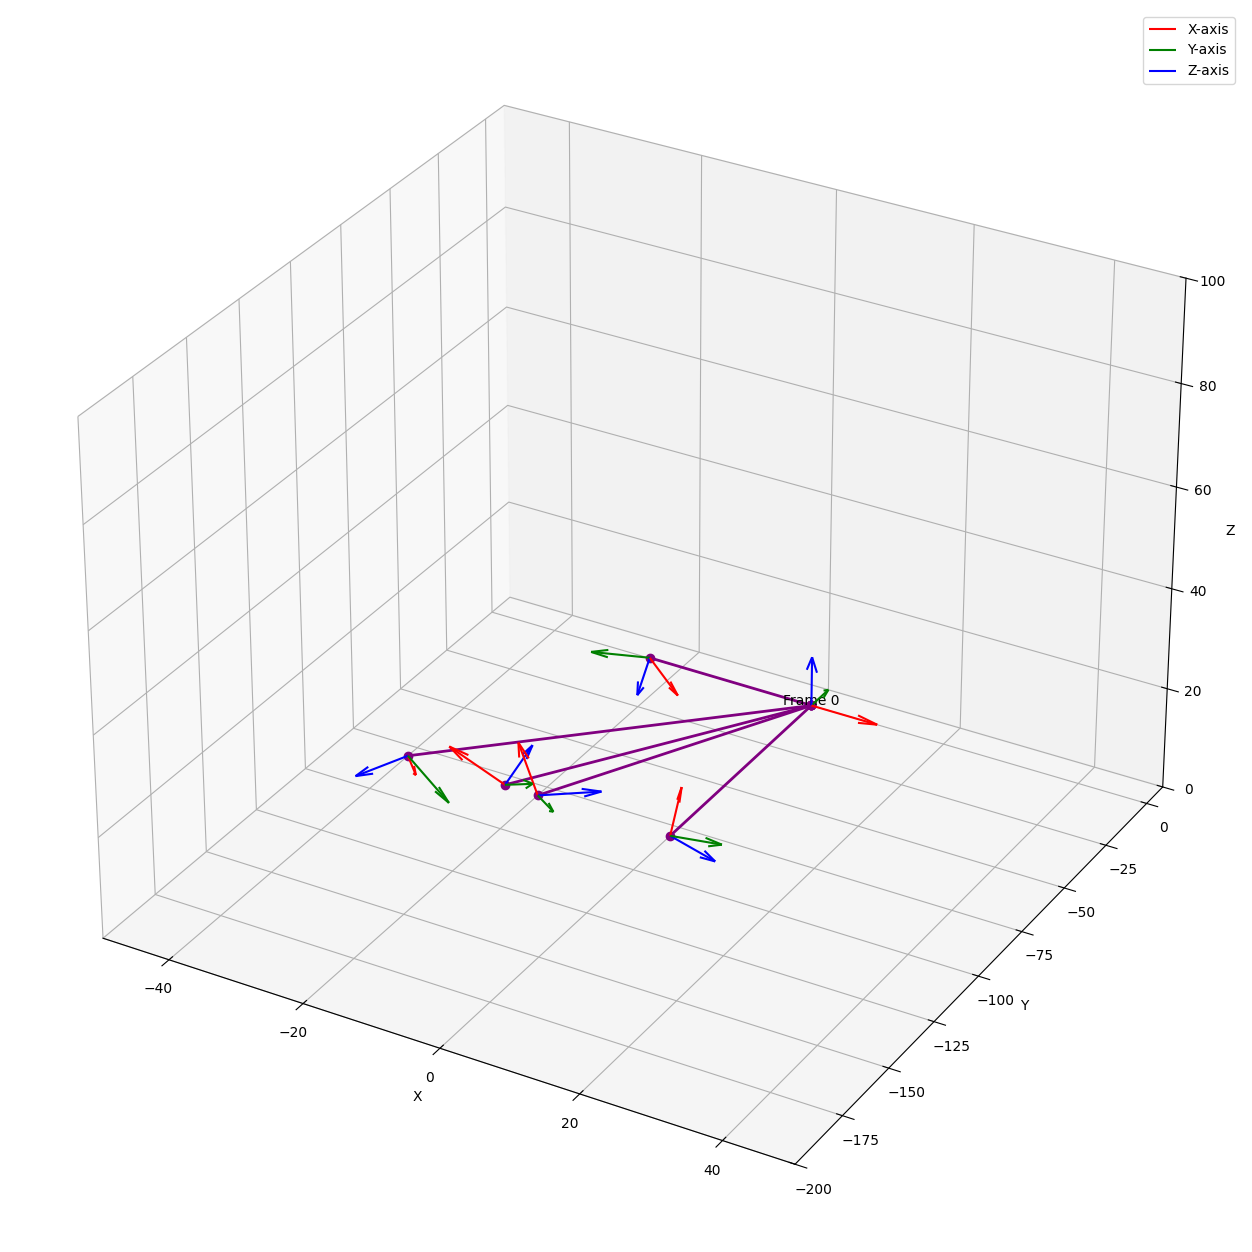

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plt.rc("figure", figsize=(20, 16))

ax.quiver(*LeftHand_Links["Palm"], *FrameArrowI, color='r', label="X-axis")  # x-axis in red
ax.quiver(*LeftHand_Links["Palm"], *FrameArrowJ, color='g', label="Y-axis")  # y-axis in green
ax.quiver(*LeftHand_Links["Palm"], *FrameArrowK, color='b', label="Z-axis")  # z-axis in blue

# Annotate the initial frame (frame 0) at origin
ax.text(LeftHand_Links["Palm"][0], LeftHand_Links["Palm"][1], LeftHand_Links["Palm"][2], f"Frame 0", color='black', fontsize=10, ha='center')


Fingers = ["Thumb", "Index", "Middle", "Ring", "Pinky"]

for i in Fingers:
    
        point = LeftHand_Transforms[i]["Palm2Proximal"][:3, 3]  # Extract translation part of the transformation

        FrameArrowI = LeftHand_Transforms[i]["Palm2Proximal"][:3, :3] @ np.array([10, 0, 0])  # X-axis (red)
        FrameArrowJ = LeftHand_Transforms[i]["Palm2Proximal"][:3, :3] @ np.array([0, 10, 0])  # Y-axis (green)
        FrameArrowK = LeftHand_Transforms[i]["Palm2Proximal"][:3, :3] @ np.array([0, 0, 10])  # Z-axis (blue)

        ax.quiver(*point, *FrameArrowI, color='r')
        ax.quiver(*point, *FrameArrowJ, color='g')
        ax.quiver(*point, *FrameArrowK, color='b')

        ax.plot([LeftHand_Links["Palm"][0], point[0]], 
                [LeftHand_Links["Palm"][1], point[1]], 
                [LeftHand_Links["Palm"][2], point[2]],
                             marker='o', linestyle='-', color='purple', linewidth=2)


for i in Fingers:
    
        point = LeftHand_Transforms[i]["Palm2Proximal"][:3, 3]  # Extract translation part of the transformation

        FrameArrowI = LeftHand_Transforms[i]["Palm2Proximal"][:3, :3] @ np.array([10, 0, 0])  # X-axis (red)
        FrameArrowJ = LeftHand_Transforms[i]["Palm2Proximal"][:3, :3] @ np.array([0, 10, 0])  # Y-axis (green)
        FrameArrowK = LeftHand_Transforms[i]["Palm2Proximal"][:3, :3] @ np.array([0, 0, 10])  # Z-axis (blue)

        ax.quiver(*point, *FrameArrowI, color='r')
        ax.quiver(*point, *FrameArrowJ, color='g')
        ax.quiver(*point, *FrameArrowK, color='b')

        ax.plot([point[0], LeftHand_Links["Palm"][0]], 
                [point[1], LeftHand_Links["Palm"][1]], 
                [point[2], LeftHand_Links["Palm"][2]],
                             marker='o', linestyle='-', color='purple', linewidth=2)





ax.set_xlim([-50, 50])
ax.set_ylim([-200, 10])
ax.set_zlim([0, 100])
ax.legend()
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')